# Inference – Pose from Cylinders (V2)

This notebook runs inference with the larger pair-geometry model in `model_v2.py`.

The original `model.py` remains unchanged for the existing small model / notebook.

The V2 model uses:

- shared patch embedding for both images
- per-image self-attention
- bidirectional cross-attention between the image streams
- camera tokens + register tokens
- learned cylinder query tokens for the `(occupancy, radius, depth)` output
- a pose head operating on the two camera tokens

The notebook keeps the same practical outputs as the old inference notebook: vision curves, cylinder overlays, relative pose, and optional training history.


In [22]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from dataset import SceneTwoPairsDataset
from model_v2 import PairImageCylinderModelV2
from utils import (
    plot_estimated_cylinders_on_images,
    plot_relative_pose,
    pose_to_text,
    show_image_pair,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Point this to the checkpoint produced by the new train.py.
CHECKPOINT = Path("arrhenius_runs/slurm_larger_model_lre4/checkpoints/latest.pt")
TEST_DATASET = Path("testdataset")

BATCH_SIZE = 4
SAMPLE_IDX = 0
OCC_THRESHOLD = 0.5

print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
print("Checkpoint:", CHECKPOINT)
print("Test dataset:", TEST_DATASET)


Device: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
CUDA: 13.0
Checkpoint: arrhenius_runs/slurm_larger_model_lre4/checkpoints/latest.pt
Test dataset: testdataset


In [24]:
checkpoint = torch.load(
    CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

args = checkpoint["args"]
print("Checkpoint epoch:", checkpoint["epoch"])
print("Model arguments:")
print(json.dumps(args, indent=2))

# V2-specific architectural arguments are read from the checkpoint when
# available, with the same defaults used by model_v2.py / train.py.
model = PairImageCylinderModelV2(
    img_size=args["img_size"],
    patch_size=args["patch_size"],
    in_chans=3,
    embed_dim=args["embed_dim"],
    depth=args["depth"],
    num_heads=args["num_heads"],
    num_bins=args["num_bins"],
    mlp_ratio=args.get("mlp_ratio", 4.0),
    num_register_tokens=args.get("num_register_tokens", 4),
    cylinder_decoder_depth=args.get("cylinder_decoder_depth", 2),
    dropout=args.get("dropout", 0.0),
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded successfully. Parameters: {n_params / 1e6:.2f} M")


Checkpoint epoch: 142
Model arguments:
{
  "data_dir": "/nobackup/proj/disk/midlevel_representations/personal/johanna/data",
  "epochs": 300,
  "batch_size": 64,
  "lr": 0.0001,
  "val_interval": 10,
  "img_size": 256,
  "patch_size": 16,
  "embed_dim": 512,
  "depth": 12,
  "num_heads": 8,
  "num_bins": 128,
  "dropout": 0.0,
  "lambda_occ": 10.0,
  "lambda_radius": 10.0,
  "occ_thresh": 0.5,
  "output_dir": "runs/slurm_larger_model_lre4"
}
Model loaded successfully. Parameters: 60.26 M


In [25]:
infer_dataset = SceneTwoPairsDataset(
    root_dir=str(TEST_DATASET),
    image_size=args["img_size"],
    return_two_pairs=False,
)

infer_loader = DataLoader(
    infer_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

print("Inference dataset size:", len(infer_dataset))


Inference dataset size: 56


In [26]:
batch = next(iter(infer_loader))
img_a, vision_a, img_b, vision_b, pose_ab = batch

img_a = img_a.to(DEVICE)
vision_a = vision_a.to(DEVICE)
img_b = img_b.to(DEVICE)
vision_b = vision_b.to(DEVICE)
pose_ab = pose_ab.to(DEVICE)

with torch.no_grad():
    pred_vision, pred_vision_b, pred_pose = model(img_a, img_b)

print("pred_vision shape:", pred_vision.shape)
print("pred_vision_b shape:", pred_vision_b.shape)
print("pred_pose shape:", pred_pose.shape)
print("GT pose:", pose_ab[SAMPLE_IDX].detach().cpu())
print("Pred pose:", pred_pose[SAMPLE_IDX].detach().cpu())
print("GT pose text:", pose_to_text(pose_ab[SAMPLE_IDX].detach().cpu()))
print("Pred pose text:", pose_to_text(pred_pose[SAMPLE_IDX].detach().cpu()))


pred_vision shape: torch.Size([4, 128, 3])
pred_vision_b shape: torch.Size([4, 128, 3])
pred_pose shape: torch.Size([4, 4])
GT pose: tensor([0.9998, 0.0193, 0.0811, 0.9967])
Pred pose: tensor([-0.7956,  0.1069, -0.0200,  0.9998])
GT pose text: tx=1.000, ty=0.019, yaw=4.7°
Pred pose text: tx=-0.796, ty=0.107, yaw=-1.1°


## 1. Input image pair


In [27]:
if False:
    show_image_pair(
        img_a[SAMPLE_IDX],
        img_b[SAMPLE_IDX],
        title=f"Inference sample {SAMPLE_IDX}",
    )


## 2. Vision prediction

Compare the predicted `(occupancy, radius, depth)` against the ground truth for image A.


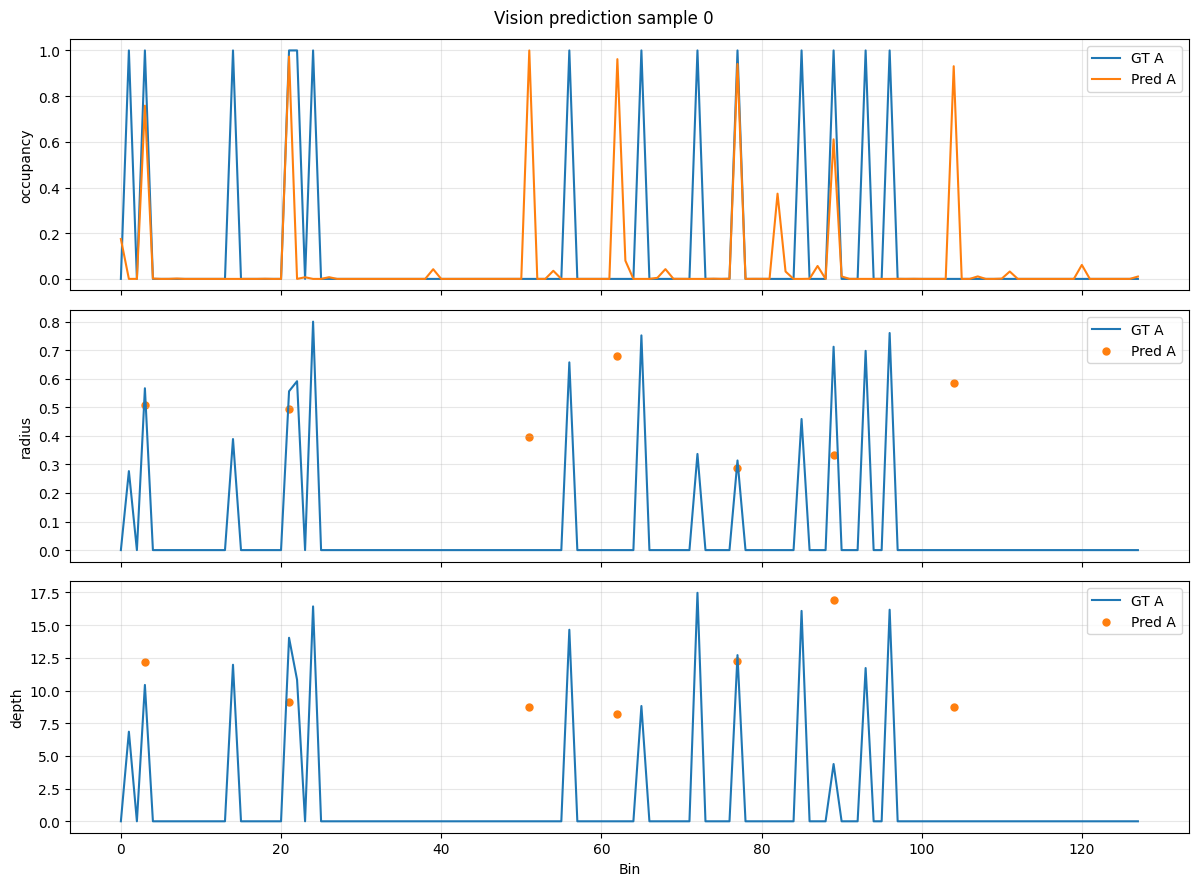

In [28]:
sample_idx = SAMPLE_IDX
bins = np.arange(pred_vision.shape[1])
occ_threshold = OCC_THRESHOLD

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
names = ["occupancy", "radius", "depth"]

gt_occ = vision_a[sample_idx, :, 0].detach().cpu().numpy()
pr_occ = pred_vision[sample_idx, :, 0].detach().cpu().numpy()

for j, ax in enumerate(axes):
    gt = vision_a[sample_idx, :, j].detach().cpu().numpy()
    pr = pred_vision[sample_idx, :, j].detach().cpu().numpy()

    ax.plot(bins, gt, label="GT A", color="tab:blue")

    if j == 0:
        ax.plot(bins, pr, label="Pred A", color="tab:orange")
    else:
        pr_mask = pr_occ > occ_threshold
        ax.scatter(
            bins[pr_mask],
            pr[pr_mask],
            label="Pred A",
            color="tab:orange",
            s=25,
        )

    ax.set_ylabel(names[j])
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Bin")
fig.suptitle(f"Vision prediction sample {sample_idx}")
plt.tight_layout()
plt.show()


## 3. Estimated cylinders and input images


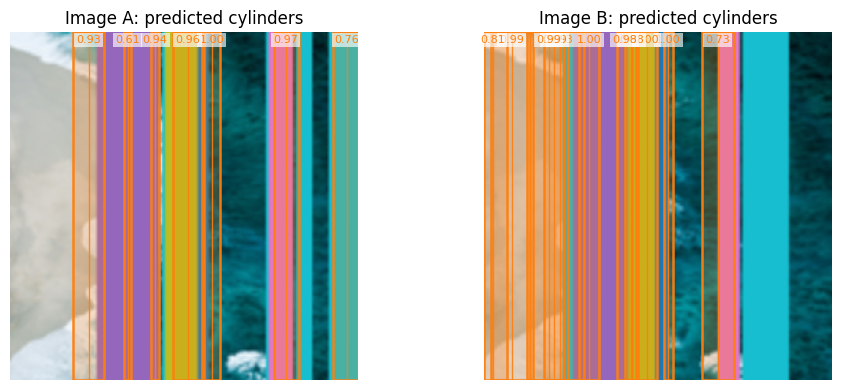

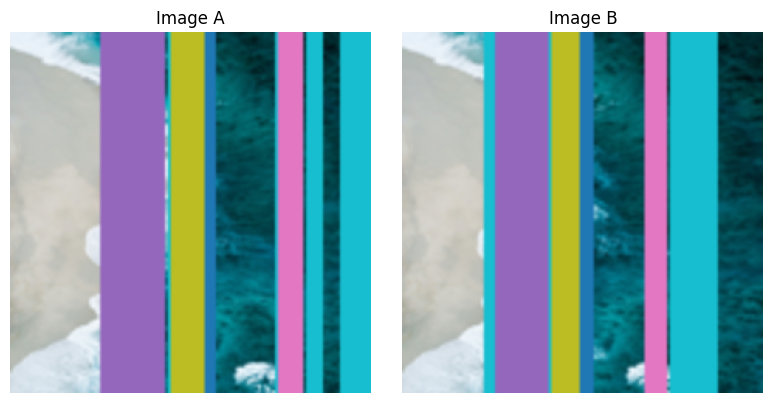

In [29]:
fig_cyl, axes_cyl = plot_estimated_cylinders_on_images(
    [img_a[SAMPLE_IDX], img_b[SAMPLE_IDX]],
    [pred_vision[SAMPLE_IDX], pred_vision_b[SAMPLE_IDX]],
    titles=["Image A: predicted cylinders", "Image B: predicted cylinders"],
    occ_threshold=OCC_THRESHOLD,
    flip_x=True,
)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_a[SAMPLE_IDX].cpu().permute(1, 2, 0))
axes[0].set_title("Image A")
axes[0].axis("off")
axes[1].imshow(img_b[SAMPLE_IDX].cpu().permute(1, 2, 0))
axes[1].set_title("Image B")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## 4. Relative pose


GT : tx=1.000, ty=0.019, yaw=4.7°
Pred: tx=-0.796, ty=0.107, yaw=-1.1°


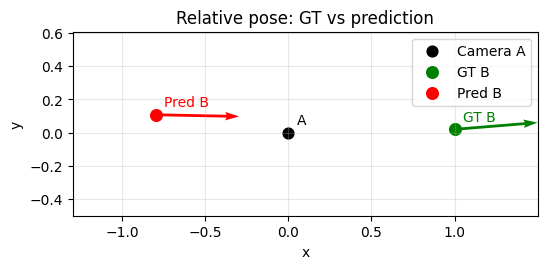

In [30]:
gt_pose = pose_ab[SAMPLE_IDX].detach().cpu()
pred_pose_sample = pred_pose[SAMPLE_IDX].detach().cpu()

print("GT :", pose_to_text(gt_pose))
print("Pred:", pose_to_text(pred_pose_sample))

plot_relative_pose(
    gt_pose,
    pred_pose_sample,
)


## 5. Training history (optional)

If `history.json` exists next to the checkpoint directory, plot the training curves.


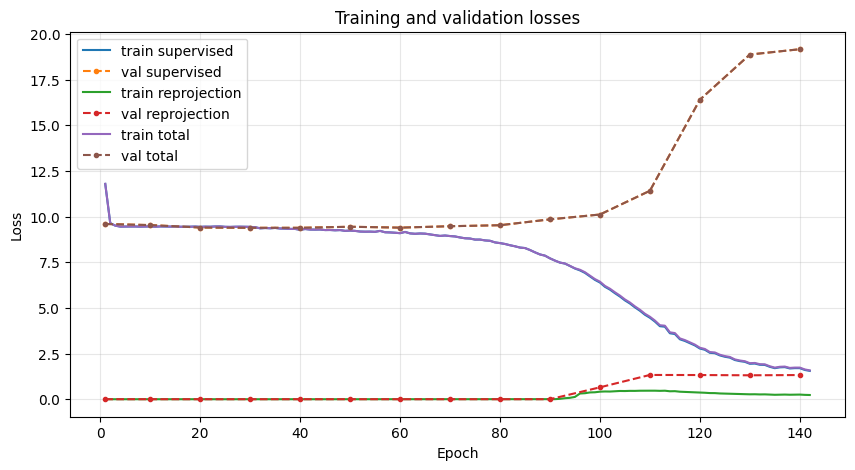

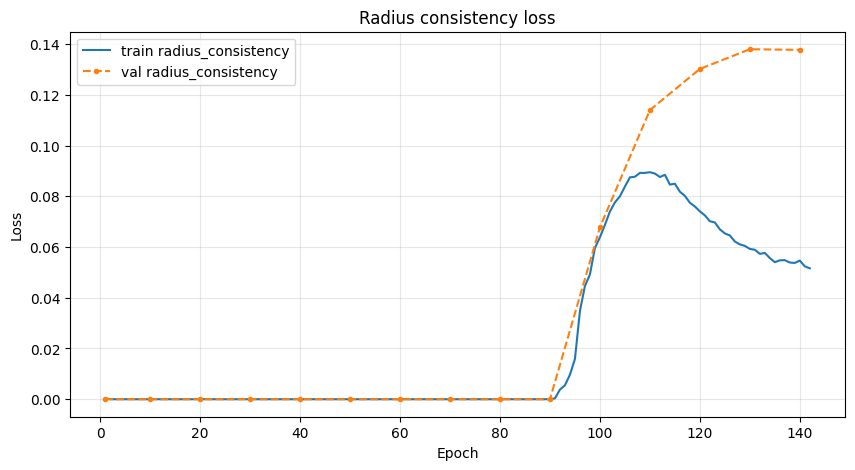

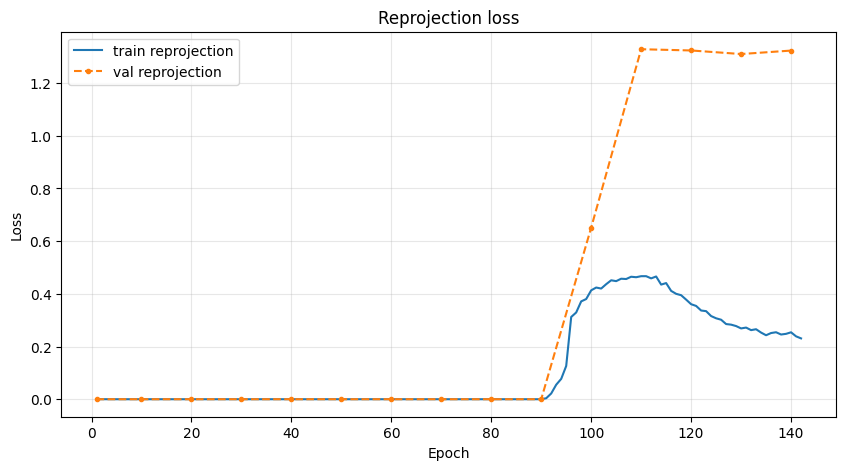

In [32]:
HISTORY = CHECKPOINT.parent.parent / "history.json"

if HISTORY.exists():
    with open(HISTORY, "r", encoding="utf-8") as f:
        history = json.load(f)

    if isinstance(history, list) and history:
        def plot_curve(group, key, *args, **kwargs):
            points = [(row.get("epoch", i + 1), row[group][key]) for i, row in enumerate(history) if key in row.get(group, {})]
            if points:
                x, y = zip(*points)
                plt.plot(x, y, *args, **kwargs)

        plt.figure(figsize=(10, 5))
        for key in ["supervised", "reprojection", "total"]:
            plot_curve("train", key, label=f"train {key}")
            if any(key in row.get("val", {}) for row in history):
                plot_curve("val", key, ".--", label=f"val {key}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and validation losses")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        # Plot pose errors when they are available in the training history.
        pose_metric_specs = [
            ("translation_error", "Translation error", "Distance"),
            ("yaw_error_deg", "Yaw error", "Degrees"),
        ]
        available_pose_metrics = [
            spec
            for spec in pose_metric_specs
            if any(
                spec[0] in row.get("train", {})
                or spec[0] in row.get("val", {})
                for row in history
            )
        ]

        if available_pose_metrics:
            fig_pose, pose_axes = plt.subplots(
                len(available_pose_metrics),
                1,
                figsize=(10, 4 * len(available_pose_metrics)),
                squeeze=False,
            )
            for ax, (key, title, ylabel) in zip(pose_axes[:, 0], available_pose_metrics):
                plt.sca(ax)
                plot_curve("train", key, label=f"train {title.lower()}")
                if any(key in row.get("val", {}) for row in history):
                    plot_curve("val", key, ".--", label=f"val {title.lower()}")
                ax.set_xlabel("Epoch")
                ax.set_ylabel(ylabel)
                ax.set_title(title)
                ax.legend()
                ax.grid(True, alpha=0.3)
            fig_pose.tight_layout()
            plt.show()

        for key, title in [("radius_consistency", "Radius consistency loss"), ("reprojection", "Reprojection loss")]:
            plt.figure(figsize=(10, 5))
            plot_curve("train", key, label=f"train {key}")
            if any(key in row.get("val", {}) for row in history):
                plot_curve("val", key, ".--", label=f"val {key}")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.title(title)
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
    else:
        print("History file is empty or has an unexpected format:", HISTORY)
else:
    print("No history.json found at:", HISTORY)
